# EDA & WordCloud 


## Exploration Data Analysis

In [1]:
# pip install -r "requirements.txt"

In [4]:
# =====================================================
# 1. IMPORT LIBRARY & DEPENDENCIES
# =====================================================
import os
import pickle
import re
from collections import Counter
from pathlib import Path
from time import perf_counter

from itables import show
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import (
    StopWordRemoverFactory,
)
from sklearn.model_selection import train_test_split
from wordcloud import STOPWORDS, WordCloud

from Preprocessing.emoji_dict import emoji_dict
from Preprocessing.normalisasi_dict import normalisasi_dict
from Preprocessing.stopwords_lstm_processing import keep_words
from Preprocessing.stopwords_wordcloud import custom_stopwords

In [6]:
# =====================================================
# 2. LOAD DATA MENTAH
# =====================================================
file_path = "Data/data_banjir.csv"

if not os.path.exists(file_path):
  raise FileNotFoundError(
      f"File tidak ditemukan di path '{file_path}'. Pastikan file dataset"
      " tersedia."
  )

try:
  data_new = pd.read_csv(
      file_path,
      sep=None,
      engine="python",
      encoding="utf-8",
      on_bad_lines="skip",
  )
except UnicodeDecodeError:
  data_new = pd.read_csv(
      file_path,
      sep=None,
      engine="python",
      encoding="latin1",
      on_bad_lines="skip",
  )

print("Kolom yang terbaca:", data_new.columns.tolist())
display(data_new.tail())

Kolom yang terbaca: ['text', 'clean_text', 'created_at', 'keyword', 'processed_text', 'sentimen', 'label', 'emoticon']


,text,clean_text,created_at,keyword,processed_text,sentimen,label,emoticon
8643,"Definisi ""membaik"" dalam konteks bencana BNPB ...",definisi membaik dalam konteks bencana bnpb bi...,2025-11-29,banjir Sumatera Barat,definisi baik konteks bencana bnpb biasa rujuk...,negatif,0.0,NaN
8644,Beberapa hari terakhir ini saudara-saudara kit...,beberapa hari terakhir ini saudara saudara kit...,2025-11-29,banjir Sumatera Barat,beberapa hari akhir saudara saudara aceh sumat...,netral,1.0,NaN
8645,BNPB ungkapkan alasan mengapa bencana banjir d...,bnpb ungkapkan alasan mengapa bencana banjir d...,2025-11-29,banjir Sumatera Barat,bnpb ungkap alas bencana banjir wilayah sumate...,netral,1.0,NaN
8646,Markas Besar Tentara Nasional Indonesia (Mabes...,markas besar tentara nasional indonesia mabes ...,2025-11-29,banjir Sumatera Barat,markas besar tentara nasional indonesia mabes ...,positif,2.0,NaN
8647,𝗗𝗮𝗿𝗺𝗮𝘄𝗮𝗻 𝗣𝗿𝗮𝘀𝗼𝗱𝗷𝗼 𝗨𝗻𝗴𝗸𝗮𝗽 𝗟𝗮𝗻𝗴𝗸𝗮𝗵 𝗣𝗟𝗡 𝗔𝘁𝗮𝘀𝗶 𝗟𝗶𝘀...,armawan rasodjo ngkap angkah tasi istrik erput...,2025-11-29,banjir Sumatera Barat,armawan rasodjo ngkap angkah tas istrik erputu...,negatif,0.0,𝗸𝗷𝗗𝗔𝗪𝗴𝗵𝗱𝘁𝘀𝗲𝗟𝗽𝗰𝗶𝗺𝘄𝗨𝗧𝘆𝗹𝗮𝗿𝗼𝗣𝗡𝘂𝗕𝗻


,Sentimen,Jumlah,Persentase
0,negatif,4843,56.00
1,positif,2340,27.06
2,netral,1465,16.94


Total data mentah: 8648


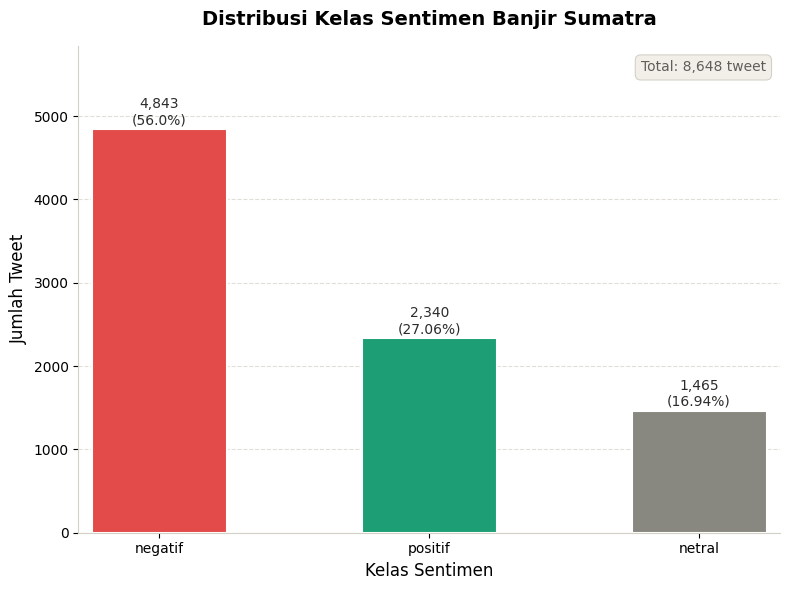

In [7]:
# =====================================================
# 3. DISTRIBUSI KELAS & VISUALISASI EDA
# =====================================================
distribusi = data_new["sentimen"].value_counts().reset_index()
distribusi.columns = ["Sentimen", "Jumlah"]
distribusi["Persentase"] = (
    distribusi["Jumlah"] / distribusi["Jumlah"].sum() * 100
).round(2)
total = sum(distribusi["Jumlah"])

df_distribusi = pd.DataFrame(distribusi)
display(df_distribusi)
print("Total data mentah:", total)

# Visualisasi Bar Chart
colors = ["#E24B4A", "#1D9E75", "#888780"]
fig, ax = plt.subplots(figsize=(8, 6))
df_plot = df_distribusi.sort_values(by="Jumlah", ascending=False)
x = np.arange(len(df_plot["Sentimen"]))
width = 0.5

bars = ax.bar(
    x,
    df_plot["Jumlah"],
    color=colors,
    width=width,
    edgecolor="white",
    linewidth=1.5,
)

for bar, jml, pct in zip(bars, df_plot["Jumlah"], df_plot["Persentase"]):
  ax.text(
      bar.get_x() + bar.get_width() / 2,
      bar.get_height() + 20,
      f"{jml:,}\n({pct}%)",
      ha="center",
      va="bottom",
      fontsize=10,
      color="#2C2C2A",
  )

ax.text(
    0.98,
    0.97,
    f"Total: {total:,} tweet",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    color="#5F5E5A",
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="#F1EFE8",
        edgecolor="#D3D1C7",
        linewidth=0.8,
    ),
)

ax.set_title(
    "Distribusi Kelas Sentimen Banjir Sumatra",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Kelas Sentimen", fontsize=12)
ax.set_ylabel("Jumlah Tweet", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(df_plot["Sentimen"])
ax.set_xlim(-0.3, 2.3)
ax.set_ylim(0, max(df_plot["Jumlah"]) + 1000)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D3D1C7")
ax.spines["bottom"].set_color("#D3D1C7")
ax.yaxis.grid(True, color="#D3D1C7", linestyle="--", alpha=0.7)
ax.set_axisbelow(True)

os.makedirs("Output/Wordcloud & Distribusi Data", exist_ok=True)
plt.tight_layout()
plt.savefig(
    "Output/Wordcloud & Distribusi Data/distribusi_sentimen.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()

In [10]:
# =====================================================
# 4. EMOTICON HANDLING (PENGGABUNGAN TEKS + EMOTIKON)
# =====================================================
def convert_emoticon(text):
  if pd.isna(text):
    return ""
  text = str(text)
  for emo in sorted(emoji_dict.keys(), key=len, reverse=True):
    text = text.replace(emo, f" {emoji_dict[emo].strip()} ")
  return re.sub(r"\s+", " ", text).strip()


data_new["emoticon"] = data_new["emoticon"].fillna("")
data_new["text_with_emoticon_raw"] = (
    data_new["text"].astype(str) + " " + data_new["emoticon"].astype(str)
)
data_new["text_with_emoticon"] = data_new["text_with_emoticon_raw"].apply(
    convert_emoticon
)

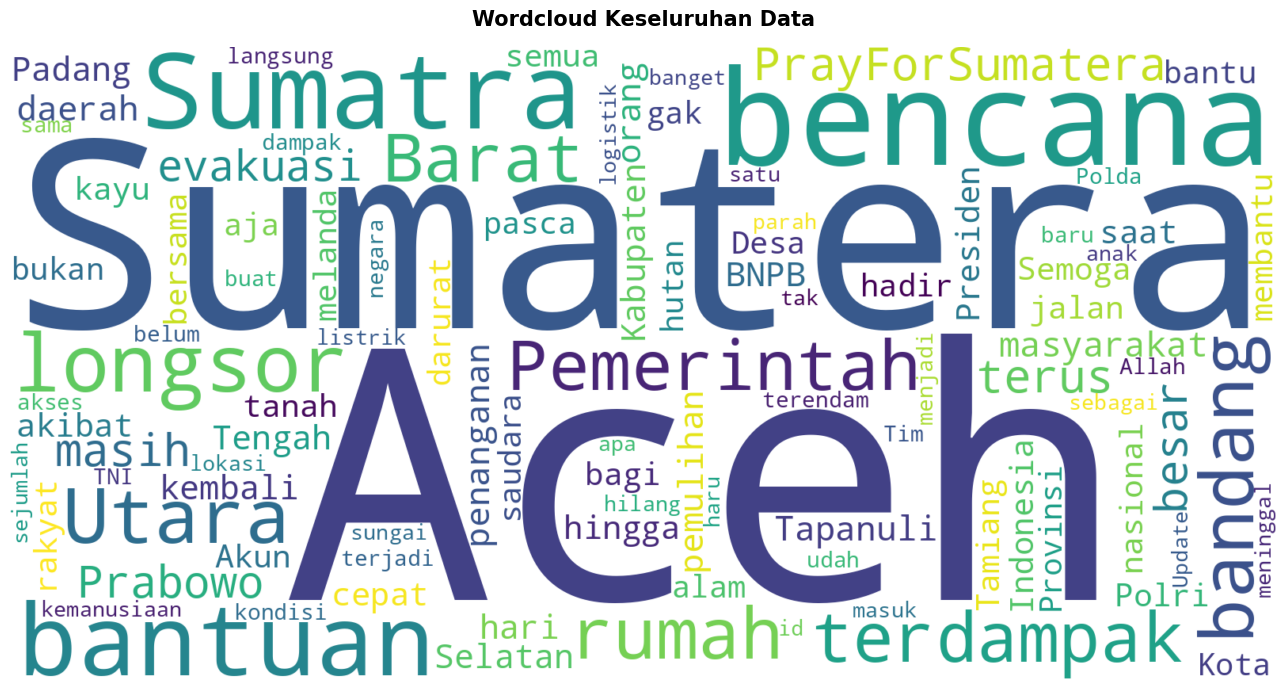

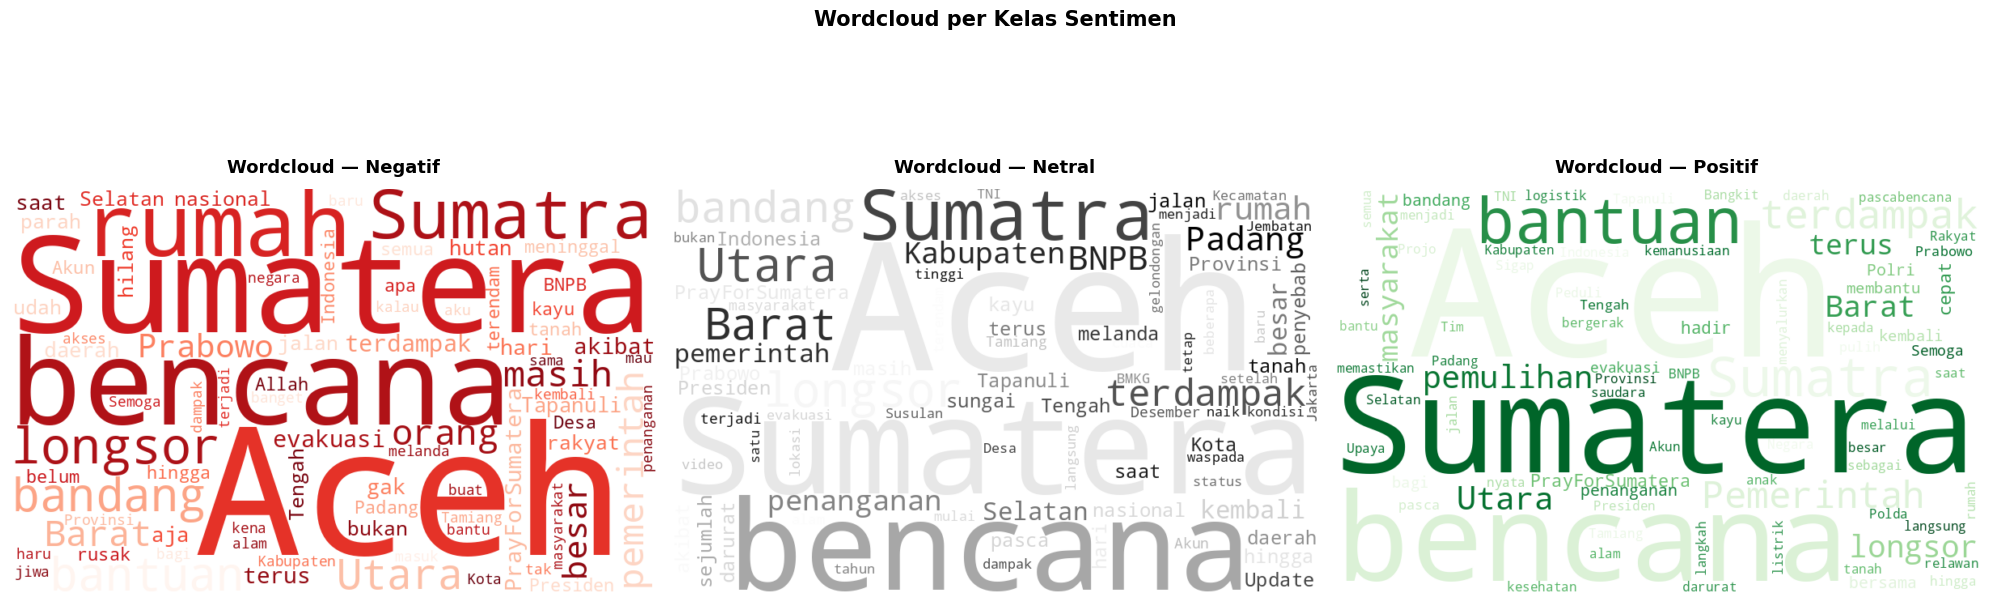

In [11]:
# =====================================================
# 5. EKSPLORASI WORDCLOUD
# =====================================================
teks_all = " ".join(data_new["text_with_emoticon"])
wc_all = WordCloud(
    width=1600,
    height=800,
    max_words=100,
    background_color="white",
    colormap="viridis",
    stopwords=custom_stopwords,
    collocations=False,
    min_font_size=10,
).generate(teks_all)

plt.figure(figsize=(14, 7))
plt.imshow(wc_all, interpolation="bilinear")
plt.axis("off")
plt.title(
    "Wordcloud Keseluruhan Data", fontsize=15, fontweight="bold", pad=15
)
plt.tight_layout()
plt.savefig(
    "Output/Wordcloud & Distribusi Data/wordcloud_keseluruhan.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()

warna = {"negatif": "Reds", "netral": "Greys", "positif": "Greens"}
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, sentimen in zip(axes, ["negatif", "netral", "positif"]):
  teks = " ".join(
      data_new[data_new["sentimen"] == sentimen]["text_with_emoticon"]
  )
  wc = WordCloud(
      width=800,
      height=500,
      max_words=80,
      background_color="white",
      colormap=warna[sentimen],
      stopwords=custom_stopwords,
      collocations=False,
      min_font_size=10,
  ).generate(teks)
  ax.imshow(wc, interpolation="bilinear")
  ax.axis("off")
  ax.set_title(
      f"Wordcloud — {sentimen.capitalize()}",
      fontsize=13,
      fontweight="bold",
      pad=12,
  )

plt.suptitle(
    "Wordcloud per Kelas Sentimen", fontsize=15, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig(
    "Output/Wordcloud & Distribusi Data/wordcloud_per_kelas.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()

In [13]:
import re
import pandas as pd
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# =====================================================
# 6. DEFINISI PREPROCESSING PER MODEL
# =====================================================
factory = StopWordRemoverFactory()
stopwords_sastrawi = set(factory.get_stop_words())
stopwords_lstm = stopwords_sastrawi - keep_words
stemmer = StemmerFactory().create_stemmer()
stem_cache = {}


def preprocess_lstm(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(
        r"\b(com|id|co|net|rb|tampilkan|membalas)\b", "", text, flags=re.I
    )
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()
    tokens = [normalisasi_dict.get(w, w) for w in tokens]
    tokens = [w for w in tokens if w not in stopwords_lstm]

    result = []
    for word in tokens:
        if word not in stem_cache:
            stem_cache[word] = stemmer.stem(word)
        result.append(stem_cache[word])
    return " ".join(result)


def preprocess_bert(text):
    if pd.isna(text):
        return ""
    text = str(text)
    # Hapus URL & Mention
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    # Hashtag tetap diambil katanya
    text = re.sub(r"#(\w+)", r"\1", text)
    # Hapus sisa crawling UI Twitter dan noise scraping
    text = re.sub(r"tampilkan lebih banyak.*", "", text, flags=re.I)
    text = re.sub(
        r"dari\s+[a-zA-Z0-9\.\-]+\.(com|id|co|net)\b.*", "", text, flags=re.I
    )
    text = re.sub(r"\b\d+\s*rb\b", "", text, flags=re.I)
    text = re.sub(r"\b\d{1,2}:\d{2}\b", "", text)
    # Rapikan simbol titik dua dan spasi ganda
    text = re.sub(r"[:]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [ ]:
# =====================================================
# 7. EKSEKUSI PREPROCESSING & LABEL ENCODING
# =====================================================
data_path = Path("Data/data_preprocessed_with_emoticon.csv")

# Jalankan preprocessing
start = perf_counter()
print("Menjalankan Preprocessing LSTM/BiLSTM...")
data_new["clean_text_lstm"] = data_new["text_with_emoticon"].apply(
    preprocess_lstm
)

print("Menjalankan Preprocessing IndoBERTweet-LoRA...")
data_new["text_bert"] = data_new["text_with_emoticon"].apply(preprocess_bert)

# Encode label ke numerik
label_map = {"negatif": 0, "netral": 1, "positif": 2}
data_new["label"] = data_new["sentimen"].map(label_map).astype(int)
df = data_new.copy()

data_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(data_path, index=False)
duration = perf_counter() - start
print(f"Selesai dan disimpan ke {data_path} dalam {duration:.2f} detik.")

display(df[["clean_text_lstm", "text_bert", "label"]].head())

Menjalankan Preprocessing LSTM/BiLSTM...


KeyboardInterrupt: 